In [1]:
import allel
print("allel:",allel.__version__)
import numpy as np
print("numpy:",np.__version__)

import re
import sys

from tabulate import tabulate
import pandas as pd

allel: 1.3.5
numpy: 1.22.3


In [18]:
from plotnine import *

In [78]:
#vcf='phased_shapeit_1_200samples.vcf.gz'
vcf='whatshap_1_bi.vcf.gz'
metafile='meta_Aaeg1kg_spp.txt'
chrom=1
#pop1='Cebu_City'; pop2='Amacuzac'; pop3='HoChiMin'

pop1='Brazil'; pop2='USA'; pop3='Argentina'

In [92]:
meta = pd.read_csv(metafile, sep='\t')
poplevel = 'country'
meta[:5]

,sample,pop,spp,region,contgroup,country
0,Debug019_aegypti_El_Dorado_Argentina_U_10,El_Dorado,ADMX,South America,Americas,Argentina
1,Debug019_aegypti_El_Dorado_Argentina_U_11,El_Dorado,ADMX,South America,Americas,Argentina
2,Debug019_aegypti_El_Dorado_Argentina_U_2,El_Dorado,ADMX,South America,Americas,Argentina
3,Debug019_aegypti_El_Dorado_Argentina_U_4,El_Dorado,ADMX,South America,Americas,Argentina
4,Debug019_aegypti_El_Dorado_Argentina_U_5,El_Dorado,ADMX,South America,Americas,Argentina


In [109]:
meta = np.genfromtxt(metafile,delimiter='\t',names=True,dtype=None,encoding='utf-8')
meta[poplevel]==pop1
meta['sample'][meta[poplevel]==pop1]

array(['Debug015_aegypti_Santarem_Brazil_L_10',
       'Debug015_aegypti_Santarem_Brazil_L_11',
       'Debug015_aegypti_Santarem_Brazil_L_12',
       'Debug015_aegypti_Santarem_Brazil_L_13',
       'Debug015_aegypti_Santarem_Brazil_L_15',
       'Debug015_aegypti_Santarem_Brazil_L_17',
       'Debug015_aegypti_Santarem_Brazil_L_18',
       'Debug015_aegypti_Santarem_Brazil_L_1',
       'Debug015_aegypti_Santarem_Brazil_L_2',
       'Debug015_aegypti_Santarem_Brazil_L_3',
       'Debug015_aegypti_Santarem_Brazil_L_4',
       'Debug015_aegypti_Santarem_Brazil_L_5',
       'Debug015_aegypti_Santarem_Brazil_L_6',
       'Debug015_aegypti_Santarem_Brazil_L_7',
       'Debug015_aegypti_Santarem_Brazil_L_8',
       'Debug015_aegypti_Santarem_Brazil_L_9',
       'Debug025_aegypti_Passo_Fundo_Brazil_M_10',
       'Debug025_aegypti_Passo_Fundo_Brazil_M_11',
       'Debug025_aegypti_Passo_Fundo_Brazil_M_12',
       'Debug025_aegypti_Passo_Fundo_Brazil_M_13',
       'Debug025_aegypti_Passo_Fundo_

In [5]:
pop1samps = meta['sample'][meta[poplevel]==pop1]
callset1 = allel.read_vcf(vcf, samples=pop1samps, fields='*')
gtpop1 = allel.GenotypeArray(callset1['calldata/GT'])
acpop1 = gtpop1.count_alleles()

/opt/miniconda3/lib/python3.9/site-packages/allel/io/vcf_read.py:1732: UserWarning: invalid INFO header: '##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">\n'


In [6]:
pop2samps = meta['sample'][meta[poplevel]==pop2]
callset2 = allel.read_vcf(vcf, samples=pop2samps, fields='*')
gtpop2 = allel.GenotypeArray(callset2['calldata/GT'])
acpop2 = gtpop2.count_alleles()

In [7]:
pop3samps = meta['sample'][meta[poplevel]==pop3]
callset3 = allel.read_vcf(vcf, samples=pop3samps, fields='*')
gtpop3 = allel.GenotypeArray(callset3['calldata/GT'])
acpop3 = gtpop3.count_alleles()

In [8]:
blen = 10000
bstep = 1000

#t,b = allel.patterson_f3(acpop3, acpop1, acpop2)
#print(sum(t)/sum(b))


f3, f3sd, f3z, f3blk, f3jack = allel.average_patterson_f3(acpop3, acpop1, acpop2, blen, normed=True)

#print(f3blk)
#print(f3jack)

/opt/miniconda3/lib/python3.9/site-packages/allel/stats/admixture.py:38: RuntimeWarning: invalid value encountered in true_divide


0.17818499725174913 0.004598362620986117 38.74966198588694


In [9]:
f3wins = allel.moving_patterson_f3(acpop3, acpop1, acpop2, blen, step=bstep, normed=True)

In [10]:
poswins = np.vstack((allel.moving_statistic(callset1['variants/POS'], min, blen, step=bstep),
            allel.moving_statistic(callset1['variants/POS'], np.average, blen, step=bstep),
            allel.moving_statistic(callset1['variants/POS'], max, blen, step=bstep))).transpose()
print(poswins.shape)
poswins

(1674, 3)


array([[6.39000000e+02, 8.64644241e+05, 1.84945200e+06],
       [2.22000000e+05, 1.04737939e+06, 2.04541600e+06],
       [3.44175000e+05, 1.22917587e+06, 2.17504900e+06],
       ...,
       [3.09416372e+08, 3.09892367e+08, 3.10387529e+08],
       [3.09503809e+08, 3.09990549e+08, 3.10513671e+08],
       [3.09608566e+08, 3.10096380e+08, 3.10702565e+08]])

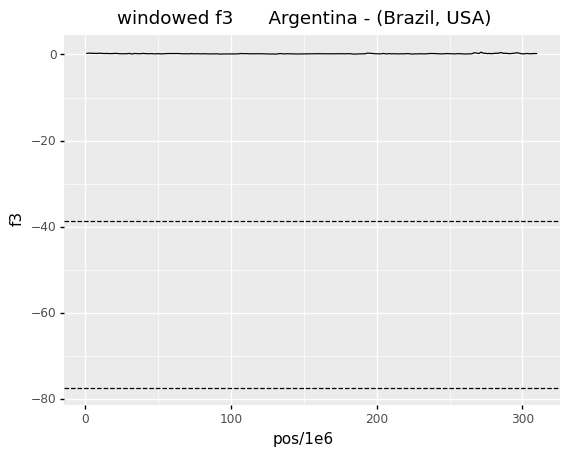

<ggplot: (396931844)>

In [17]:
f3tab = pd.DataFrame(data=np.vstack([poswins[:,1],f3wins]).transpose(),columns=["pos","f3"])

p = ggplot(f3tab,aes(x='pos/1e6',y="f3")) + \
  geom_line() + geom_hline(yintercept=[0-(f3z),0-(f3z*2)],linetype="dashed")+ \
  ggtitle("windowed f3      {p3} - ({p1}, {p2})".format(p1=pop1,p2=pop2,p3=pop3)) 
#ggsave(plot=p, filename='panel_assess_full_posn_pop.png', dpi=400)
p

In [71]:
print("\t".join(map(str,[pop3,pop1,pop2,chrom,f3,f3sd,f3z,f3<(-2*f3z)])))

Argentina	Brazil	USA	1	0.17818499725174913	0.004598362620986117	38.74966198588694	False
